In [7]:
# %%
"""
📌 Notebook: 08_model_evaluation.ipynb

🎯 Purpose:
Evaluate and compare LSTM, GRU, and Transformer models.

🔥 Features:
- Accuracy comparison
- Training history comparison
- Confusion matrix
- Classification report
"""

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
from sklearn.metrics import confusion_matrix, classification_report

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [8]:
# %%
# Load models
lstm_model = tf.keras.models.load_model("../models/lstm_model.h5")
gru_model = tf.keras.models.load_model("../models/gru_model.h5")
transformer_model = tf.keras.models.load_model("../models/transformer_model.h5")

# Load history
with open('../results/lstm_history.pkl', 'rb') as f:
    lstm_h = pickle.load(f)
with open('../results/gru_history.pkl', 'rb') as f:
    gru_h = pickle.load(f)
with open('../results/transformer_history.pkl', 'rb') as f:
    trans_h = pickle.load(f)

print("✅ Models and histories loaded.")

✅ Models and histories loaded.


In [9]:
X_test = np.load("../processed_data/X_test.npy")
y_test = np.load("../processed_data/y_test.npy")

# IMPORTANT (your fix)
y_test = y_test - 1

print("Test data loaded successfully!")

Test data loaded successfully!


In [10]:
# %%
"""
🔹 Accuracy Comparison
"""

models_list = {
    "LSTM": lstm_model,
    "GRU": gru_model,
    "Transformer": transformer_model
}

acc_results = {}

for name, model in models_list.items():
    _, acc = model.evaluate(X_test, y_test, verbose=0)
    acc_results[name] = acc
    print(f"{name} Accuracy: {acc*100:.2f}%")

LSTM Accuracy: 90.34%
GRU Accuracy: 90.83%
Transformer Accuracy: 85.41%


In [11]:
# %%
"""
📊 Save Comparison Table
"""

df_compare = pd.DataFrame({
    'Model': list(acc_results.keys()),
    'Test_Accuracy': [f"{v*100:.2f}%" for v in acc_results.values()]
})

df_compare.to_csv('../results/model_comparison.csv', index=False)
print("✅ Comparison CSV saved.")

✅ Comparison CSV saved.


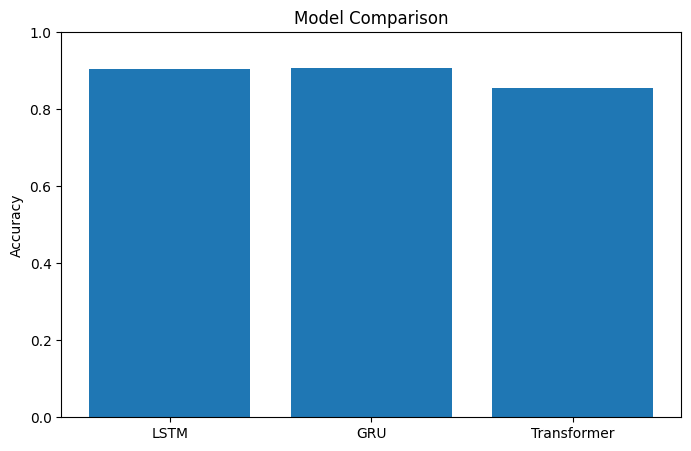

In [12]:
# %%
"""
📊 Accuracy Bar Chart
"""

plt.figure(figsize=(8, 5))
plt.bar(acc_results.keys(), acc_results.values())

plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)

plt.savefig('../results/graphs/final_accuracy_comparison.png')
plt.show()

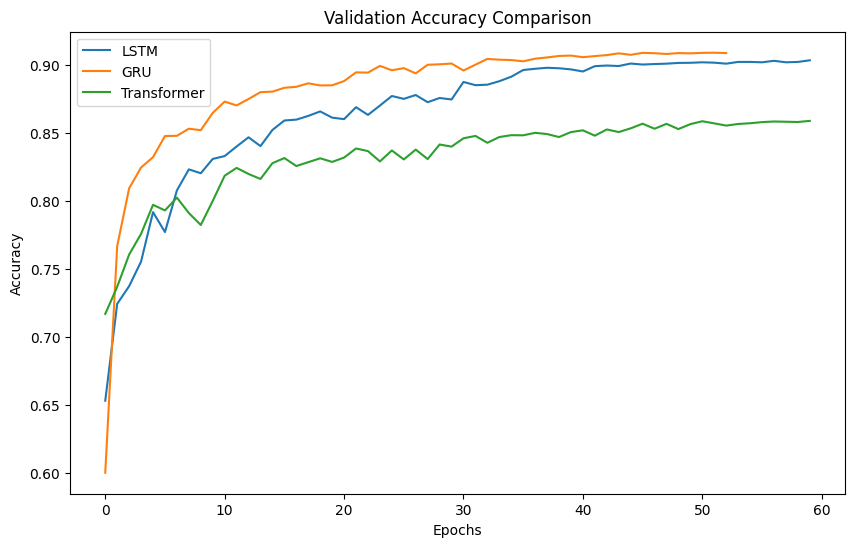

In [13]:
# %%
"""
📈 Training History Comparison
"""

plt.figure(figsize=(10, 6))

plt.plot(lstm_h['val_accuracy'], label='LSTM')
plt.plot(gru_h['val_accuracy'], label='GRU')
plt.plot(trans_h['val_accuracy'], label='Transformer')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('../results/graphs/training_history_comparison.png')
plt.show()

In [14]:
# %%
"""
🏆 Best Model Evaluation
"""

best_model_name = max(acc_results, key=acc_results.get)
best_model = models_list[best_model_name]

print(f"🏆 Best Model: {best_model_name}")

y_pred = np.argmax(best_model.predict(X_test), axis=1)

🏆 Best Model: GRU
855/855 [==============================] - 14s 15ms/step


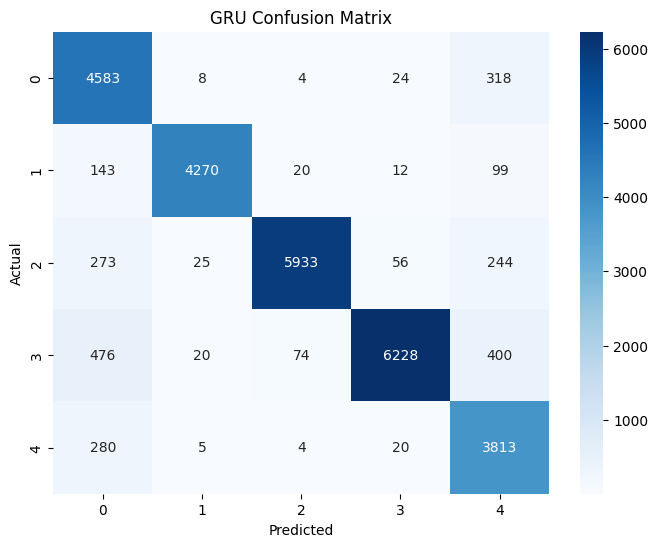

In [15]:
# %%
"""
📊 Confusion Matrix
"""

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[0,1,2,3,4],
    yticklabels=[0,1,2,3,4]
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'{best_model_name} Confusion Matrix')

plt.savefig(f'../results/confusion_matrix/{best_model_name}_cm.png')
plt.show()

In [16]:
# %%
"""
📄 Classification Report
"""

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))


📊 Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.93      0.86      4937
           1       0.99      0.94      0.96      4544
           2       0.98      0.91      0.94      6531
           3       0.98      0.87      0.92      7198
           4       0.78      0.93      0.85      4122

    accuracy                           0.91     27332
   macro avg       0.91      0.91      0.91     27332
weighted avg       0.92      0.91      0.91     27332

